<a href="https://colab.research.google.com/github/GHseyram/Ghana-energy-transition-investment-analytics/blob/main/notebooks/python/01_python_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
project_name = "Ghana Energy Transition Investment Analytics"
data_year = 2025
total_generation_gwh = 27945

print("Project:", project_name)
print("Data year:", data_year)
print("Total electricity generation:", total_generation_gwh, "GWh")

Project: Ghana Energy Transition Investment Analytics
Data year: 2025
Total electricity generation: 27945 GWh


In [2]:
thermal_generation_gwh = 18996

thermal_share = (thermal_generation_gwh / total_generation_gwh) * 100

print("Thermal generation share:", round(thermal_share, 2), "%")

Thermal generation share: 67.98 %


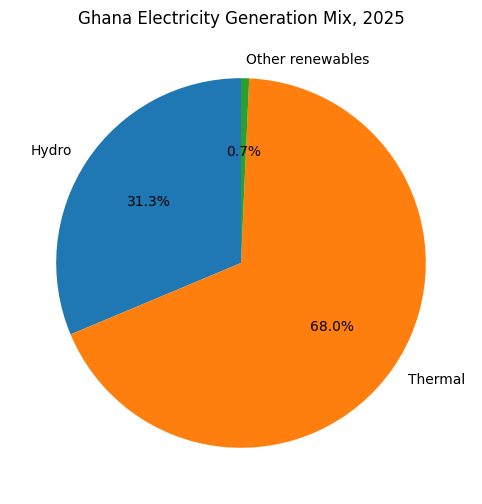

In [3]:
import matplotlib.pyplot as plt

generation_sources = ["Hydro", "Thermal", "Other renewables"]
generation_gwh = [8752, 18996, 197]

plt.figure(figsize=(8, 6))

plt.pie(
    generation_gwh,
    labels=generation_sources,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ghana Electricity Generation Mix, 2025")
plt.show()

In [5]:
import pandas as pd

data_url = "https://raw.githubusercontent.com/GHseyram/Ghana-energy-transition-investment-analytics/main/data/ghana-energy-baseline-2025.csv"

energy_data = pd.read_csv(data_url)

generation_data = energy_data[
    energy_data["indicator"].str.contains(
        "generation",
        case=False,
        na=False
    )
    & (energy_data["unit"] == "GWh")
].copy()

generation_data[["indicator", "value", "unit"]]

,indicator,value,unit
8,Total electricity generation,27945.0,GWh
9,Hydro electricity generation,8752.0,GWh
10,Thermal electricity generation,18996.0,GWh
11,Other renewable electricity generation,197.0,GWh


In [6]:
gwh_data = energy_data[energy_data["unit"] == "GWh"]

generation_data = gwh_data[
    gwh_data["indicator"].str.contains(
        "generation",
        case=False,
        na=False
    )
]

generation_data[["indicator", "value", "unit"]]


,indicator,value,unit
8,Total electricity generation,27945.0,GWh
9,Hydro electricity generation,8752.0,GWh
10,Thermal electricity generation,18996.0,GWh
11,Other renewable electricity generation,197.0,GWh


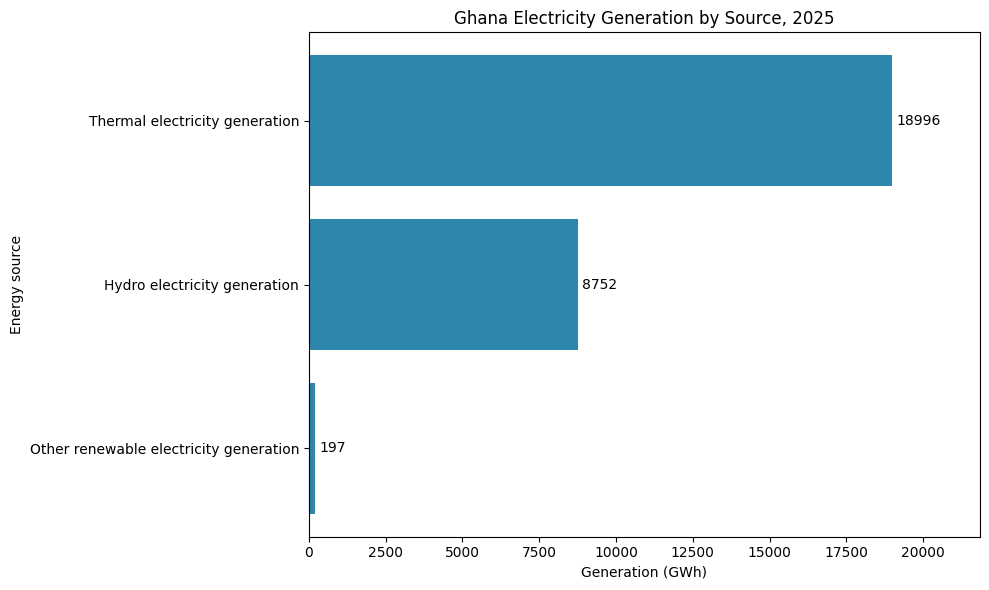

In [7]:
import matplotlib.pyplot as plt

plot_data = generation_data[
    ~generation_data["indicator"].str.contains(
        "total",
        case=False,
        na=False
    )
].copy()

plot_data = plot_data.sort_values("value")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["indicator"],
    plot_data["value"],
    color="#2E86AB"
)

plt.bar_label(bars, fmt="%.0f", padding=3)

plt.title("Ghana Electricity Generation by Source, 2025")
plt.xlabel("Generation (GWh)")
plt.ylabel("Energy source")
plt.xlim(0, plot_data["value"].max() * 1.15)
plt.tight_layout()
plt.show()